 # interp saes

In [ ]:
# SETUP

import os
import sys

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from scipy import stats
import wandb

# Import notebook utilities
from src.utils.nb_utils import setup_notebook, load_transformer_model, load_sae

# Import project utilities
from src.utils.runtime import configure_runtime
from src.models.transformer import parse_model_name_safe, build_attention_mask
from src.models.utils import load_model
from src.data.datasets import get_dataset
from src.sae.sae_analysis import (
    collect_sae_activations,
    create_feature_heatmaps,
    compute_reconstruction_metrics,
    compute_sae_patched_accuracy,
    identify_special_features,
    load_sae_from_wandb_run,
    compare_sweep_runs,
)

# Setup device and seeds
DEVICE = setup_notebook(seed=42)

# --- Configuration ---
MODEL_NAME = '2layer_100dig_64d'
# looking at:
SAE_NAME = "sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt" # MSE: 0.0042, Recon Acc: 0.8688 (old - not as high accuracy as below)
# SAE_NAME = "sae_d100_k3_lr0.0001_seed43_2layer_100dig_64d.pt" # MSE: 0.0036, Recon Acc: 0.8752
# SAE_NAME = "sae_d100_k4_50ksteps_2layer_100dig_64d.pt" # (classic - best recon accuracy of 0.8885) 


# Output Config
SAVE_RESULTS = False
SAVE_DIR = "../results/sae_results/" if SAVE_RESULTS else None

# --- Load Models ---
model, model_cfg = load_transformer_model(MODEL_NAME, device=DEVICE)

# Extract config for convenience
D_MODEL = model_cfg['d_model']
N_LAYERS = model_cfg['n_layers']
N_HEADS = model_cfg['n_heads']
LIST_LEN = model_cfg['list_len']
N_DIGITS = model_cfg['n_digits']
SEP_TOKEN_INDEX = model_cfg['sep_token_index']

# Load SAE
sae, sae_cfg = load_sae(SAE_NAME, D_MODEL, device=DEVICE)
D_SAE = sae_cfg['dict_size']
TOP_K = sae_cfg['k']

# Load activation mean from checkpoint (for centering)
SAE_PATH = os.path.join('../results/sae_models', SAE_NAME)
sae_checkpoint = torch.load(SAE_PATH, map_location=DEVICE, weights_only=False)
act_mean = sae_checkpoint["act_mean"].to(DEVICE)

Using device: mps
Parsed model config (old format): 2 layers, 100 digits, 64 d_model, list_len=2
Loading model from ../models/2layer_100dig_64d.pt
Moving model to device:  mps
✓ Loaded model from ../models/2layer_100dig_64d.pt
✓ Loaded SAE from ../results/sae_models/sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt
  - Dictionary size: 100
  - Top-K: 3


In [ ]:
# Load validation dataset and collect SAE activations
train_ds, val_ds = get_dataset(
    n_digits=N_DIGITS,
    list_len=LIST_LEN,
    no_dupes=False,
    train_dupes_only=False
)
# concat both
all_ds = torch.utils.data.ConcatDataset([train_ds, val_ds])

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False)
all_dl = DataLoader(all_ds, batch_size=128, shuffle=False)

# Collect SAE activations for ALL data (not getting acccuracy so it's fine to incl train)
d1_all, d2_all, sae_acts_all = collect_sae_activations(
    model=model,
    sae=sae,
    val_dl=all_dl, 
    act_mean=act_mean,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

In [ ]:
# basic metrics

# L0 Sparsity
l0 = (sae_acts_all > 0).float().sum(dim=1).mean()
print(f"Average L0 (active features per sample): {l0:.2f}")

# Dead features
dead_features = (sae_acts_all.sum(dim=0) == 0).sum().item()
print(f"Dead features: {dead_features} / {D_SAE} ({100*dead_features/D_SAE:.1f}%)")

# Feature firing rates
firing_rate = (sae_acts_all > 0).float().mean(dim=0)
print(f"Firing rate range: [{firing_rate[firing_rate > 0].min():.4f}, {firing_rate.max():.4f}]")

Average L0 (active features per sample): 3.02
Dead features: 0 / 100 (0.0%)
Firing rate range: [0.0199, 0.7054]


In [ ]:
# SAE Reconstruction Accuracy - model performance with SAE-reconstructed activations

acc_metrics = compute_sae_patched_accuracy( 
    model=model,
    sae=sae,
    val_dl=val_dl, # MUST use val_dl
    act_mean=act_mean,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

print(f"
{'='*60}")
print("SAE RECONSTRUCTION ACCURACY")
print(f"{'='*60}")
print(f"Baseline accuracy:        {acc_metrics['baseline_acc']:.4f} ({acc_metrics['baseline_acc']*100:.2f}%)")
print(f"SAE reconstruction acc:   {acc_metrics['reconstruction_acc']:.4f} ({acc_metrics['reconstruction_acc']*100:.2f}%)")
print(f"Accuracy drop:            {acc_metrics['accuracy_drop']:.4f} ({acc_metrics['accuracy_drop']*100:.2f}%)")
print(f"Total samples evaluated:  {acc_metrics['total_samples']}")
print(f"{'='*60}
")


SAE RECONSTRUCTION ACCURACY
Baseline accuracy:        0.9145 (91.45%)
SAE reconstruction acc:   0.8688 (86.88%)
Accuracy drop:            0.0457 (4.57%)
Total samples evaluated:  4000



In [ ]:
# Feature heatmaps (Plotly interactive)
fig = create_feature_heatmaps(
    d1_all=d1_all,
    d2_all=d2_all,
    sae_acts_all=sae_acts_all,
    n_digits=N_DIGITS,
    figsize=(20, 20)
)
if SAVE_RESULTS:
    fig.write_html(f"{SAVE_DIR}sae_feature_heatmaps.html")
    fig.write_image(f"{SAVE_DIR}sae_feature_heatmaps.png")
fig.show()

Reconstruction MSE: 0.008945
Explained variance: 0.9763
Per-sample MSE - Mean: 0.008945, Std: 0.019601


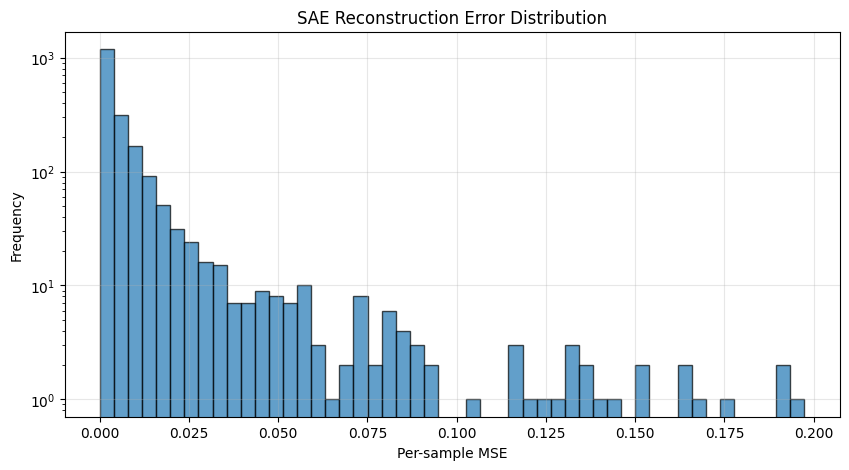

In [ ]:
# Reconstruction metrics
recon_metrics = compute_reconstruction_metrics(
    model=model,
    sae=sae,
    val_dl=val_dl,
    act_mean=act_mean,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

print(f"Reconstruction MSE: {recon_metrics['mse']:.6f}")
print(f"Explained variance: {recon_metrics['explained_variance']:.4f}")
print(f"Per-sample MSE - Mean: {recon_metrics['per_sample_mse'].mean():.6f}, Std: {recon_metrics['per_sample_mse'].std():.6f}")

# Plot MSE distribution
plt.figure(figsize=(10, 5))
plt.hist(recon_metrics['per_sample_mse'].numpy(), bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Per-sample MSE')
plt.ylabel('Frequency')
plt.title(f'SAE Reconstruction Error Distribution')
plt.yscale('log')
plt.grid(alpha=0.3)
if SAVE_RESULTS:
    plt.savefig(f"{SAVE_DIR}sae_recon_mse_dist.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Identify special features (requires attention weights)
# Extract attention weights from SEP token to input positions
with torch.no_grad():
    alpha_d1_all = []
    alpha_d2_all = []
    
    for inputs, _ in tqdm(all_dl, desc="Extracting attention weights", leave=False):
        inputs = inputs.to(DEVICE)
        
        # Run model with attention cache
        logits, cache = model.run_with_cache(inputs)
        
        # Get attention scores from SEP token (position LIST_LEN) in layer 0
        attn_layer0 = cache["blocks.0.attn.hook_attn_scores"]  # [batch, n_heads, seq_len, seq_len]
        
        # SEP attends to d1 and d2 (positions 0 and 1)
        sep_pos = SEP_TOKEN_INDEX
        alpha_d1 = attn_layer0[:, :, sep_pos, 0].mean(dim=1)  # Average over heads
        alpha_d2 = attn_layer0[:, :, sep_pos, 1].mean(dim=1)
        
        alpha_d1_all.append(alpha_d1.cpu())
        alpha_d2_all.append(alpha_d2.cpu())

alpha_d1_all = torch.cat(alpha_d1_all)
alpha_d2_all = torch.cat(alpha_d2_all)

# Identify special features
special_features_info = identify_special_features(
    sae_acts_all=sae_acts_all,
    alpha_d1_all=alpha_d1_all,
    alpha_d2_all=alpha_d2_all,
    threshold=0.5
)

print(f"Special features (|corr| > 0.5): {special_features_info['n_special_features']}")
print(f"Max correlation: {special_features_info['max_correlation']:.4f}")
print(f"Mean abs correlation: {special_features_info['mean_abs_correlation']:.4f}")

if special_features_info['special_features']:
    print("
Top special features:")
    top_special = sorted(
        special_features_info['special_features'],
        key=lambda x: abs(x['correlation']),
        reverse=True
    )[:10]
    for feat in top_special:
        print(f"  Feature {feat['feature_idx']}: {feat['type']}, corr={feat['correlation']:.4f}")

Special features (|corr| > 0.5): 1
Max correlation: 0.7996
Mean abs correlation: 0.0102

Top special features:
  Feature 30: d2_favoring, corr=-0.7996


In [ ]:
feature_firing_freq = (sae_acts_all > 0).float().mean(dim=0).numpy()
active_features = np.where(feature_firing_freq > 0)[0]
n_active = len(active_features)

# Sort by firing frequency
sorted_indices = np.argsort(feature_firing_freq)[::-1]
top_n = min(30, n_active)

In [ ]:
# 2. Activation strength analysis per feature


# Mean activation strength (when active)
mean_act_strength = []
for i in range(D_SAE):
    active_mask = sae_acts_all[:, i] > 0
    if active_mask.any():
        mean_act_strength.append(sae_acts_all[active_mask, i].mean().item())
    else:
        mean_act_strength.append(0)
mean_act_strength = np.array(mean_act_strength)

# Top features by mean strength
top_strength_idx = np.argsort(mean_act_strength)[::-1][:top_n]


# Firing frequency vs mean strength scatter
active_mask = feature_firing_freq > 0

# Max activation per feature
max_act_strength = sae_acts_all.max(dim=0)[0].numpy()


# Total activation (sum over all samples)
total_activation = sae_acts_all.sum(dim=0).numpy()
top_total_idx = np.argsort(total_activation)[::-1][:top_n]

In [ ]:
def compute_feature_digit_stats(feat_idx, d1_all, d2_all, sae_acts_all, n_digits=100):
    """
    Compute digit distribution statistics for a feature.
    
    Returns dict with:
        - n_inputs: number of inputs that activate this feature
        - all_digit_dist: percentage distribution across all 2n digits
        - d1_digit_dist: percentage distribution for d1 positions only
        - d2_digit_dist: percentage distribution for d2 positions only
    """
    # Find inputs where feature activates
    active_mask = sae_acts_all[:, feat_idx] > 0
    n_inputs = active_mask.sum().item()
    
    if n_inputs == 0:
        return {
            'n_inputs': 0,
            'all_digit_dist': np.zeros(n_digits),
            'd1_digit_dist': np.zeros(n_digits),
            'd2_digit_dist': np.zeros(n_digits),
        }
    
    # Get active d1 and d2 values
    d1_active = d1_all[active_mask].numpy()
    d2_active = d2_all[active_mask].numpy()
    
    # Count digit occurrences
    d1_counts = np.bincount(d1_active, minlength=n_digits)
    d2_counts = np.bincount(d2_active, minlength=n_digits)
    all_counts = d1_counts + d2_counts
    
    # Convert to percentages
    total_digits = 2 * n_inputs
    all_digit_dist = 100 * all_counts / total_digits
    d1_digit_dist = 100 * d1_counts / n_inputs
    d2_digit_dist = 100 * d2_counts / n_inputs
    
    return {
        'n_inputs': n_inputs,
        'all_digit_dist': all_digit_dist,
        'd1_digit_dist': d1_digit_dist,
        'd2_digit_dist': d2_digit_dist,
    }

# Compute for top features
n_features_to_analyze = min(20, n_active)
top_features = top_total_idx[:n_features_to_analyze]

feature_stats = {}
for special_feat_idx in tqdm(top_features, desc="Computing digit stats"):
    feature_stats[special_feat_idx] = compute_feature_digit_stats(
        special_feat_idx, d1_all, d2_all, sae_acts_all, N_DIGITS
    )

Computing digit stats: 100%|██████████| 20/20 [00:00<00:00, 7049.84it/s]


In [ ]:
# Display digit distribution table for top features
print(f"
{'='*100}")
print(f"DIGIT DISTRIBUTION ANALYSIS FOR TOP {n_features_to_analyze} FEATURES")
print(f"{'='*100}
")

for special_feat_idx in top_features[:10]:  # Show first 10
    stats = feature_stats[special_feat_idx]
    n_inputs = stats['n_inputs']
    
    print(f"
{'─'*100}")
    print(f"Feature {special_feat_idx}: Activates on {n_inputs} inputs ({n_inputs*2} total digits)")
    print(f"{'─'*100}")
    
    # Find top digits overall
    all_dist = stats['all_digit_dist']
    top_digits_all = np.argsort(all_dist)[::-1][:10]
    
    print(f"
Top digits (combined d1 + d2):")
    for digit in top_digits_all:
        if all_dist[digit] > 0:
            print(f"  Digit {digit:2d}: {all_dist[digit]:5.1f}%")
    
    # Find top digits for d1 and d2 separately
    d1_dist = stats['d1_digit_dist']
    d2_dist = stats['d2_digit_dist']
    top_digits_d1 = np.argsort(d1_dist)[::-1][:5]
    top_digits_d2 = np.argsort(d2_dist)[::-1][:5]
    
    print(f"
Top d1 digits:")
    for digit in top_digits_d1:
        if d1_dist[digit] > 0:
            print(f"  Digit {digit:2d}: {d1_dist[digit]:5.1f}%")
    
    print(f"
Top d2 digits:")
    for digit in top_digits_d2:
        if d2_dist[digit] > 0:
            print(f"  Digit {digit:2d}: {d2_dist[digit]:5.1f}%")


DIGIT DISTRIBUTION ANALYSIS FOR TOP 20 FEATURES


────────────────────────────────────────────────────────────────────────────────────────────────────
Feature 30: Activates on 7054 inputs (14108 total digits)
────────────────────────────────────────────────────────────────────────────────────────────────────

Top digits (combined d1 + d2):
  Digit 72:   1.4%
  Digit 19:   1.4%
  Digit 81:   1.4%
  Digit 38:   1.4%
  Digit 30:   1.2%
  Digit 37:   1.1%
  Digit 40:   1.1%
  Digit 47:   1.1%
  Digit 11:   1.1%
  Digit 71:   1.1%

Top d1 digits:
  Digit  0:   1.4%
  Digit 58:   1.4%
  Digit 70:   1.4%
  Digit 69:   1.4%
  Digit 68:   1.4%

Top d2 digits:
  Digit 99:   1.4%
  Digit 75:   1.4%
  Digit 72:   1.4%
  Digit 63:   1.4%
  Digit 62:   1.4%

────────────────────────────────────────────────────────────────────────────────────────────────────
Feature 65: Activates on 843 inputs (1686 total digits)
───────────────────────────────────────────────────────────────────────────────────────

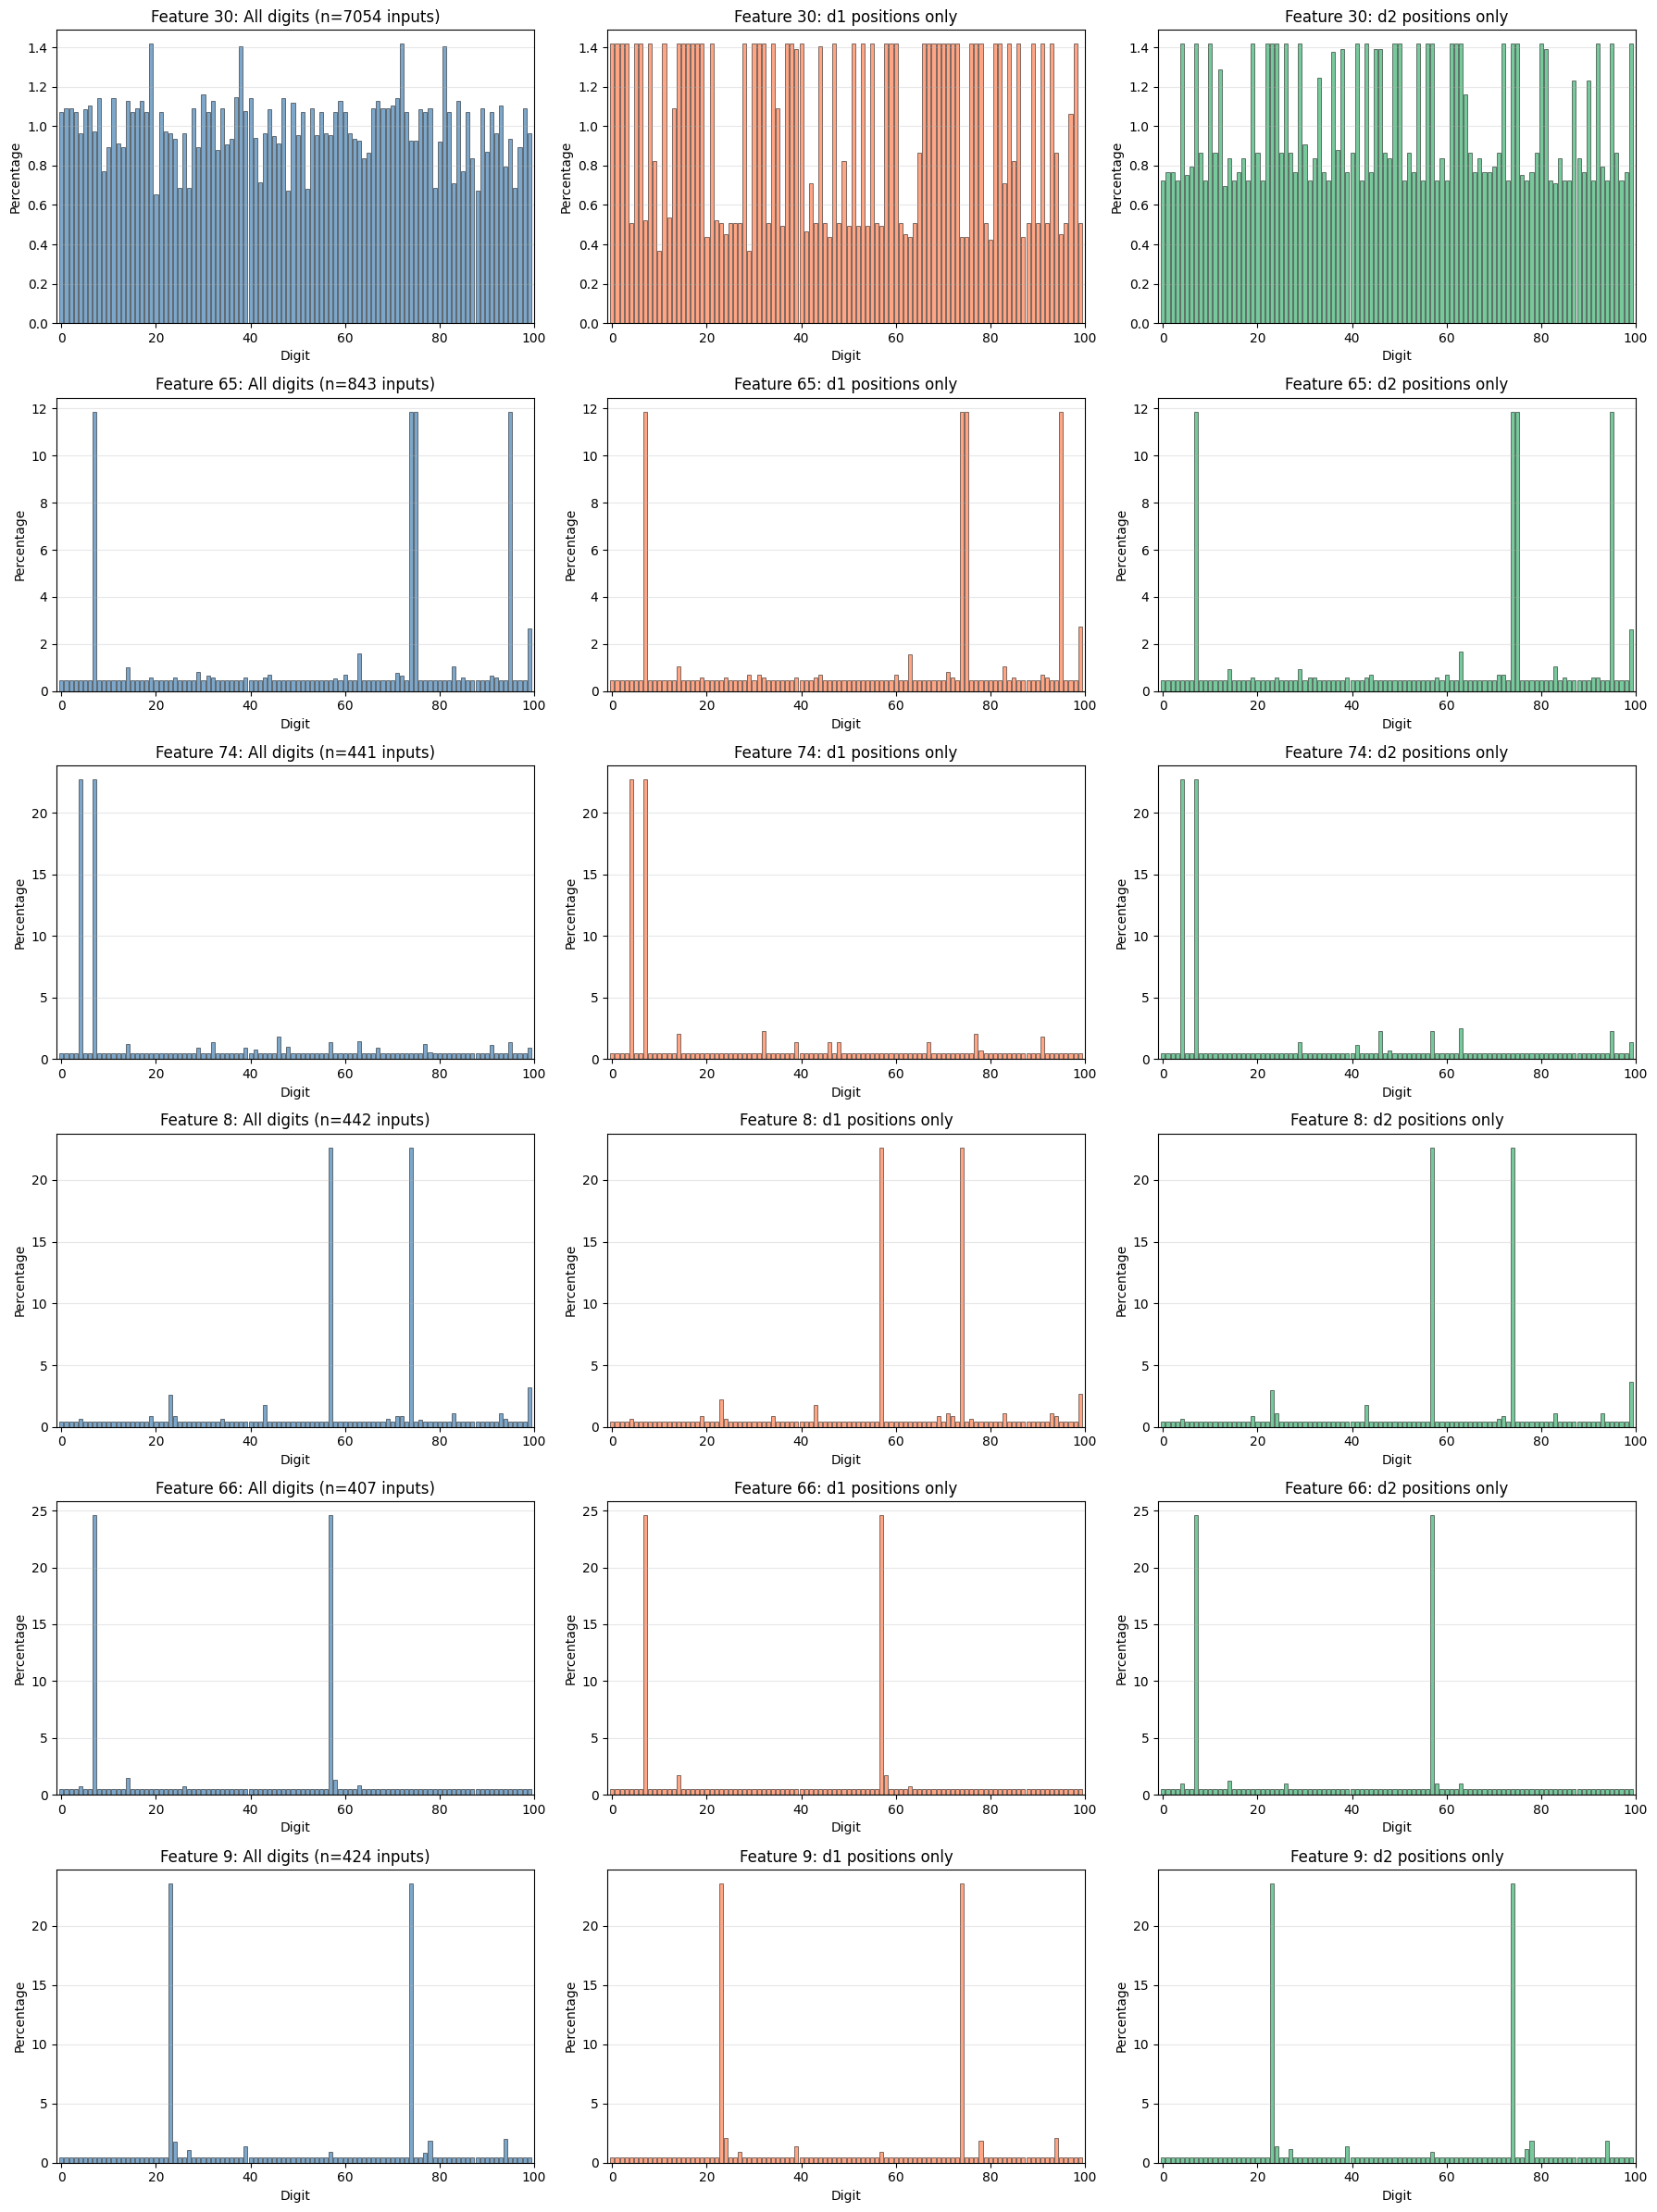

In [ ]:
# Visualize digit distributions for top features
n_vis = min(6, len(top_features))
fig, axes = plt.subplots(n_vis, 3, figsize=(18, 4*n_vis))
if n_vis == 1:
    axes = axes[np.newaxis, :]

for idx, special_feat_idx in enumerate(top_features[:n_vis]):
    stats = feature_stats[special_feat_idx]
    
    # Plot combined distribution
    ax = axes[idx, 0]
    digits = np.arange(N_DIGITS)
    ax.bar(digits, stats['all_digit_dist'], color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Digit')
    ax.set_ylabel('Percentage')
    ax.set_title(f'Feature {special_feat_idx}: All digits (n={stats["n_inputs"]} inputs)')
    ax.grid(alpha=0.3, axis='y')
    ax.set_xlim(-1, N_DIGITS)
    
    # Plot d1 distribution
    ax = axes[idx, 1]
    ax.bar(digits, stats['d1_digit_dist'], color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Digit')
    ax.set_ylabel('Percentage')
    ax.set_title(f'Feature {special_feat_idx}: d1 positions only')
    ax.grid(alpha=0.3, axis='y')
    ax.set_xlim(-1, N_DIGITS)
    
    # Plot d2 distribution
    ax = axes[idx, 2]
    ax.bar(digits, stats['d2_digit_dist'], color='mediumseagreen', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Digit')
    ax.set_ylabel('Percentage')
    ax.set_title(f'Feature {special_feat_idx}: d2 positions only')
    ax.grid(alpha=0.3, axis='y')
    ax.set_xlim(-1, N_DIGITS)

plt.tight_layout()
if SAVE_RESULTS:
    plt.savefig(f"{SAVE_DIR}sae_digit_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Create comprehensive dataframe for all features
rows = []
for special_feat_idx in top_features:
    stats = feature_stats[special_feat_idx]
    
    # Get top 5 digits for each category
    all_dist = stats['all_digit_dist']
    d1_dist = stats['d1_digit_dist']
    d2_dist = stats['d2_digit_dist']
    
    top5_all = np.argsort(all_dist)[::-1][:5]
    top5_d1 = np.argsort(d1_dist)[::-1][:5]
    top5_d2 = np.argsort(d2_dist)[::-1][:5]
    
    # Format as strings
    top_all_str = ", ".join([f"{d}({all_dist[d]:.1f}%)" for d in top5_all if all_dist[d] > 0])
    top_d1_str = ", ".join([f"{d}({d1_dist[d]:.1f}%)" for d in top5_d1 if d1_dist[d] > 0])
    top_d2_str = ", ".join([f"{d}({d2_dist[d]:.1f}%)" for d in top5_d2 if d2_dist[d] > 0])
    
    rows.append({
        'Feature': special_feat_idx,
        'N_Inputs': stats['n_inputs'],
        'Fire_Rate_%': feature_firing_freq[special_feat_idx] * 100,
        'Top_All_Digits': top_all_str,
        'Top_D1_Digits': top_d1_str,
        'Top_D2_Digits': top_d2_str,
    })

df_digit_stats = pd.DataFrame(rows)
print(f"
{'='*120}")
print("COMPREHENSIVE DIGIT DISTRIBUTION TABLE")
print(f"{'='*120}
")
print(df_digit_stats.to_string(index=False))

if SAVE_RESULTS:
    df_digit_stats.to_csv(f"{SAVE_DIR}sae_digit_distributions.csv", index=False)
    print(f"
Saved to {SAVE_DIR}sae_digit_distributions.csv")


COMPREHENSIVE DIGIT DISTRIBUTION TABLE

 Feature  N_Inputs  Fire_Rate_%                                      Top_All_Digits                                       Top_D1_Digits                                       Top_D2_Digits
      30      7054    70.539999    72(1.4%), 19(1.4%), 81(1.4%), 38(1.4%), 30(1.2%)     0(1.4%), 58(1.4%), 70(1.4%), 69(1.4%), 68(1.4%)    99(1.4%), 75(1.4%), 72(1.4%), 63(1.4%), 62(1.4%)
      65       843     8.430000 7(11.9%), 95(11.9%), 74(11.9%), 75(11.9%), 99(2.7%) 7(11.9%), 74(11.9%), 95(11.9%), 75(11.9%), 99(2.7%) 95(11.9%), 74(11.9%), 75(11.9%), 7(11.9%), 99(2.6%)
      74       441     4.410000    4(22.7%), 7(22.7%), 46(1.8%), 63(1.5%), 95(1.4%)    4(22.7%), 7(22.7%), 32(2.3%), 14(2.0%), 77(2.0%)    7(22.7%), 4(22.7%), 63(2.5%), 46(2.3%), 95(2.3%)
       8       442     4.420000  74(22.6%), 57(22.6%), 99(3.2%), 23(2.6%), 43(1.8%)  74(22.6%), 57(22.6%), 99(2.7%), 23(2.3%), 43(1.8%)  57(22.6%), 74(22.6%), 99(3.6%), 23(2.9%), 43(1.8%)
      66       407 

 After running this for all 4 SAEs at the top, the 100d SAEs seem to have learned the identity function.
 the 50d ones are more interesting

 Looking at `sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt`, let's inspect feature 30 (fires on 1433 / 10000 inputs with 71% fire rate)

In [ ]:
special_feat_idx = 30

special_feat_acts = sae_acts_all[:, special_feat_idx]

spec_feat_active = special_feat_acts > 0

print(f"
F{special_feat_idx} fires when α_d1 > α_d2: {(spec_feat_active & (alpha_d1_all > alpha_d2_all)).sum() / spec_feat_active.sum() * 100:.1f}%")
print(f"F{special_feat_idx} fires when α_d2 > α_d1: {(spec_feat_active & (alpha_d2_all > alpha_d1_all)).sum() / spec_feat_active.sum() * 100:.1f}%")

#  the features fire when the attention is higher for one digit than the other


F30 fires when α_d1 > α_d2: 34.8%
F30 fires when α_d2 > α_d1: 65.2%


In [ ]:
# Setup hook for SAE patching
from src.sae.sae_analysis import make_sae_patch_hook

hook_name_resid = f"blocks.0.hook_resid_post"

Feature 30 fires on 7054 / 10000 inputs


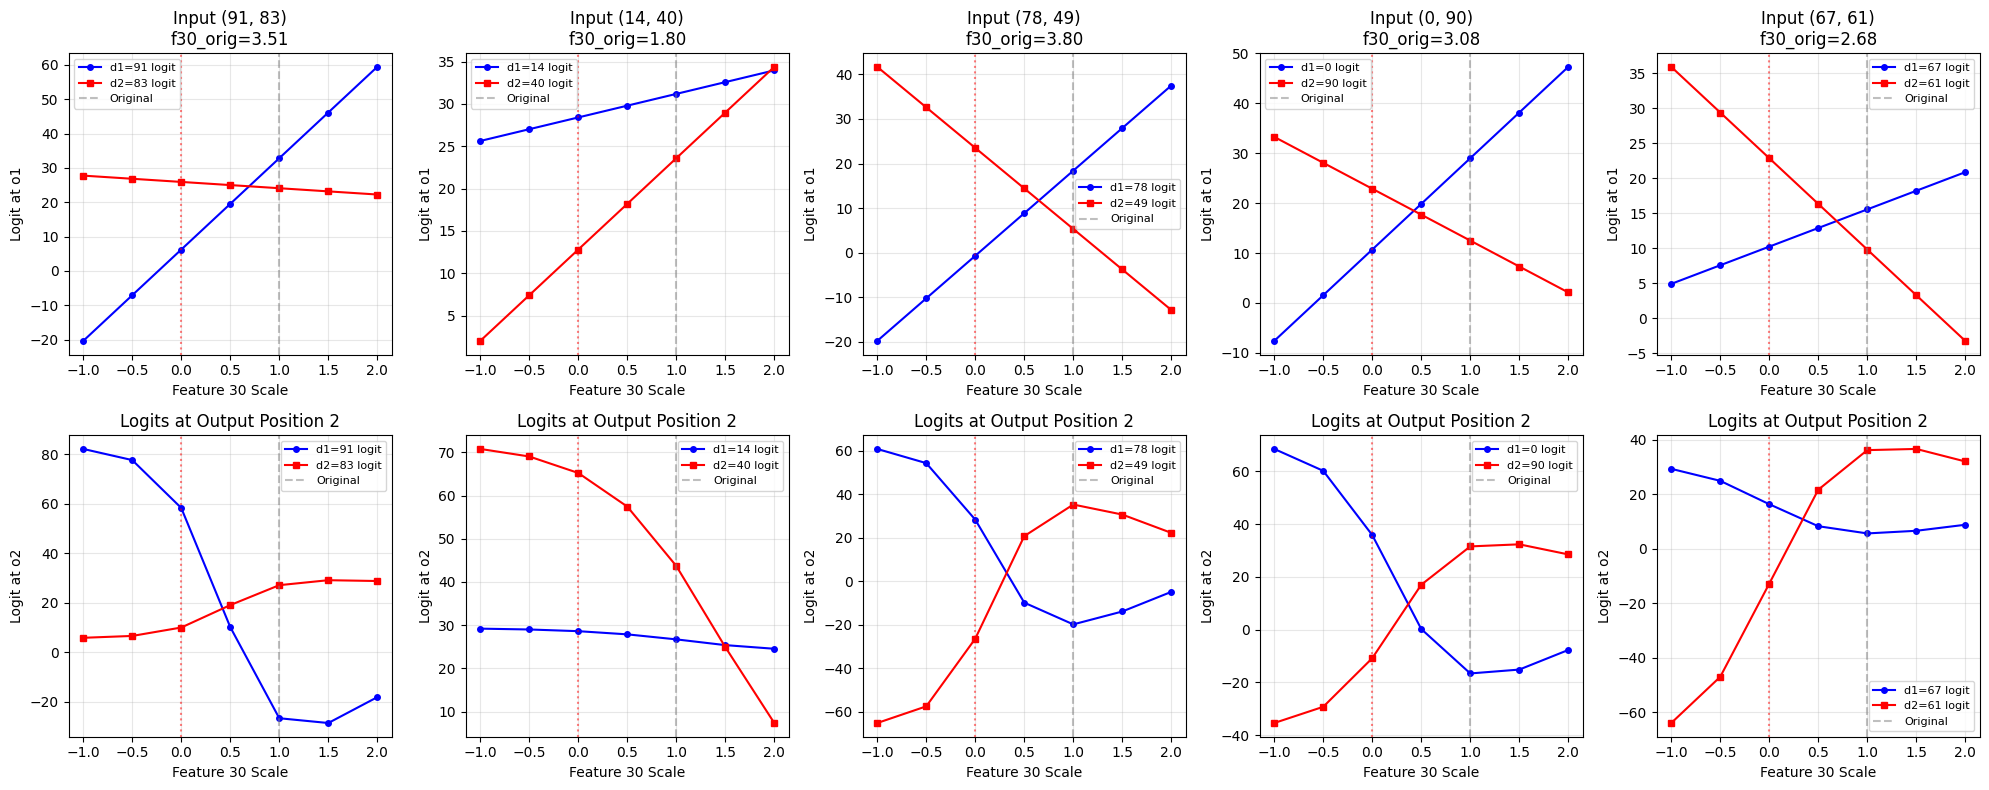

In [ ]:
# lets try some steering on random pairs for special feat

# Select test cases where the feature ACTUALLY FIRES
active_indices = torch.where(sae_acts_all[:, special_feat_idx] > 0)[0]
print(f"Feature {special_feat_idx} fires on {len(active_indices)} / {len(d1_all)} inputs")

# Sample from active inputs only
np.random.seed(42)
test_indices = np.random.choice(active_indices.numpy(), size=min(5, len(active_indices)), replace=False)
test_pairs = [(d1_all[i].item(), d2_all[i].item()) for i in test_indices]

# Extended scale range: -1 to 2 to test negative scaling (reversing the feature)
scale_factors = np.array([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0])

# Storage for plotting
all_results = []

for d1_val, d2_val in test_pairs:
    # Find this pair in dataset
    mask = (d1_all == d1_val) & (d2_all == d2_val)
    if mask.sum() == 0:
        continue
    idx = torch.where(mask)[0][0].item()
    
    # Get inputs from all_ds (since idx is from all_dl)
    inputs_i = all_ds[idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[idx].clone().to(DEVICE)
    order_feat_orig = z_orig[special_feat_idx].item()
    
    logit_d1_at_o1 = []
    logit_d2_at_o1 = []
    logit_d1_at_o2 = []
    logit_d2_at_o2 = []
    output_o1 = []
    output_o2 = []
    
    for scale in scale_factors:
        z_scaled = z_orig.clone()
        z_scaled[special_feat_idx] = order_feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, act_mean, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1)
        logits_o1 = patched_logits[0, -2, :N_DIGITS]
        logits_o2 = patched_logits[0, -1, :N_DIGITS]
        
        logit_d1_at_o1.append(logits_o1[d1_val].item())
        logit_d2_at_o1.append(logits_o1[d2_val].item())
        logit_d1_at_o2.append(logits_o2[d1_val].item())
        logit_d2_at_o2.append(logits_o2[d2_val].item())
        output_o1.append(logits_o1.argmax().item())
        output_o2.append(logits_o2.argmax().item())
    
    all_results.append({
        'd1': d1_val, 'd2': d2_val,
        'scales': scale_factors,
        'logit_d1_o1': logit_d1_at_o1,
        'logit_d2_o1': logit_d2_at_o1,
        'logit_d1_o2': logit_d1_at_o2,
        'logit_d2_o2': logit_d2_at_o2,
        'output_o1': output_o1,
        'output_o2': output_o2,
        'order_feat_orig': order_feat_orig,
    })

# Plot results
fig, axes = plt.subplots(2, len(all_results), figsize=(4*len(all_results), 8), squeeze=False)

for col, result in enumerate(all_results):
    d1, d2 = result['d1'], result['d2']
    scales = result['scales']
    
    # Top row: Logits at o1 position

    ax1 = axes[0, col]
    ax1.plot(scales, result['logit_d1_o1'], 'b-o', label=f'd1={d1} logit', markersize=4)
    ax1.plot(scales, result['logit_d2_o1'], 'r-s', label=f'd2={d2} logit', markersize=4)
    ax1.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='red', linestyle=':', alpha=0.5)
    ax1.set_xlabel(f'Feature {special_feat_idx} Scale')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'Input ({d1}, {d2})
f{special_feat_idx}_orig={result["order_feat_orig"]:.2f}')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Bottom row: Logits at o2 position
    ax2 = axes[1, col]
    ax2.plot(scales, result['logit_d1_o2'], 'b-o', label=f'd1={d1} logit', markersize=4)
    ax2.plot(scales, result['logit_d2_o2'], 'r-s', label=f'd2={d2} logit', markersize=4)
    ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='red', linestyle=':', alpha=0.5)
    ax2.set_xlabel(f'Feature {special_feat_idx} Scale')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'Logits at Output Position 2')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_DIR: plt.savefig(os.path.join(SAVE_DIR, f'feature_{special_feat_idx}_logit_steering.png'), dpi=150, bbox_inches='tight')
plt.show()